### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [1]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

# [vk denovo](https://github.com/pachterlab/varseek) on NA12878 (GIAB HG001) — benchmarked against ground truth

This notebook runs the **varseek de novo** pipeline (`vk denovo` → `vk ref` → `vk count`) on
**NA12878 / HG001** whole-genome sequencing reads, then compares the calls **directly to the
Genome in a Bottle (GIAB) HG001 v4.2.1 truth set** with `hap.py` — the standard germline
small-variant benchmarking tool.

**Scope: chromosome 20** (the canonical GIAB benchmarking chromosome), in the GIAB
high-confidence regions. This keeps the demo tractable while giving a real ground-truth
comparison.

**Data**
- Reads: GIAB NIST `RMNISTHS_30xdownsample.bam` (NA12878, ~30×), chr20 reads only, re-aligned to GRCh38.
- Reference: Ensembl GRCh38 primary assembly (already used by `vk_denovo.ipynb`).
- Truth: `HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz` + high-confidence `.bed`, restricted to chr20
  and renamed to Ensembl contig naming (`chr20` → `20`).

> Because the input is whole-genome **DNA** (not RNA), `vk denovo` aligns with **bowtie2**
> (DNA aligner) rather than STAR, and `vk count` runs in `bulk`/`paired` mode.


### Define paths and parameters

In [2]:
import os, re, gzip, subprocess
import numpy as np
import pandas as pd
import anndata as ad
import pysam

# ---- reference (shared with vk_denovo.ipynb) ----
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "Homo_sapiens.GRCh38.dna.primary_assembly.fa")

# ---- NA12878 chr20 working dir ----
root = os.path.join("data", "na12878_chr20")
reads_dir = os.path.join(root, "reads")
r1 = os.path.join(reads_dir, "NA12878_chr20_R1.fastq.gz")
r2 = os.path.join(reads_dir, "NA12878_chr20_R2.fastq.gz")
chr20_bam = os.path.join(reads_dir, "chr20.bam")

bowtie2_index_prefix = os.path.join(reference_dir, "bowtie2_chr20", "chr20")

# vk denovo out
variants_dir = os.path.join(root, "variants")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")

# vk ref out
vk_ref_out_dir = os.path.join(root, "varseek_ref_out")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join(root, "varseek_count_out")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# GIAB truth
giab_dir = os.path.join(root, "giab")
truth_vcf = os.path.join(giab_dir, "truth_chr20_ens.vcf.gz")
confident_bed = os.path.join(giab_dir, "confident_chr20_ens.bed")

# hap.py out
happy_out = os.path.join(root, "happy_output")

# general parameters
w = 37
k = 41
min_counts_denovo = 3
min_counts_clean = 1
threads = 16
read_length = 148


### Download NA12878 chr20 reads (GIAB 30× BAM) and re-align target

We stream only the **chr20** reads from the GIAB NIST 30× downsampled NA12878 BAM, then convert
them to paired FASTQ. Reads are reference-agnostic, so although that BAM is GRCh37-aligned we
re-align to GRCh38 below.

In [4]:
GIAB_30X_BAM = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data/NA12878/"
                "NIST_NA12878_HG001_HiSeq_300x/RMNISTHS_30xdownsample.bam")

os.makedirs(reads_dir, exist_ok=True)
if not (os.path.exists(r1) and os.path.exists(r2)):
    if not os.path.exists(chr20_bam):
        subprocess.run(["samtools", "view", "-@", str(threads), "-b", GIAB_30X_BAM, "20",
                        "-o", chr20_bam], check=True)
    # collate into read pairs, then emit paired FASTQ (singletons dropped)
    collate = subprocess.Popen(["samtools", "collate", "-@", str(threads), "-u", "-O",
                                chr20_bam, os.path.join(reads_dir, "collate_tmp")],
                               stdout=subprocess.PIPE)
    subprocess.run(["samtools", "fastq", "-@", str(threads), "-1", r1, "-2", r2,
                    "-0", "/dev/null", "-s", os.path.join(reads_dir, "singletons.fastq.gz"),
                    "-n", "-"], stdin=collate.stdout, check=True)
    collate.wait()

n_pairs = sum(1 for _ in gzip.open(r1, "rt")) // 4
print(f"NA12878 chr20 read pairs: {n_pairs:,}")


NA12878 chr20 read pairs: 6,633,667


### Build a chr20 bowtie2 index

`vk denovo` aligns DNA reads with bowtie2. The reads were extracted from chr20, so a chr20 index
suffices and is fast to build.

In [5]:
bt2_dir = os.path.dirname(bowtie2_index_prefix)
os.makedirs(bt2_dir, exist_ok=True)
if not os.path.exists(bowtie2_index_prefix + ".1.bt2"):
    chr20_fa = bowtie2_index_prefix + ".fa"
    subprocess.run(f"samtools faidx {sequences} 20 > {chr20_fa}", shell=True, check=True)
    subprocess.run(["bowtie2-build", "--threads", str(threads), chr20_fa, bowtie2_index_prefix],
                   check=True)
print("bowtie2 chr20 index ready:", bowtie2_index_prefix)


bowtie2 chr20 index ready: data/reference/bowtie2_chr20/chr20


### Prepare the GIAB ground-truth VCF and high-confidence BED (chr20, Ensembl naming)

The GIAB truth uses UCSC contig names (`chr20`); our reference uses Ensembl naming (`20`). We
subset to chr20, rename, and left-normalize the truth against the reference. The high-confidence
BED defines where the benchmark is valid — both `vk denovo` calling and `hap.py` evaluation are
restricted to it.

In [6]:
os.makedirs(giab_dir, exist_ok=True)
GIAB_REL = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/"
            "NA12878_HG001/NISTv4.2.1/GRCh38")
raw_vcf = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.vcf.gz")
raw_bed = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.bed")

if not os.path.exists(truth_vcf):
    if not os.path.exists(raw_vcf):
        subprocess.run(["curl", "-sL", "-o", raw_vcf,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"], check=True)
        subprocess.run(["curl", "-sL", "-o", raw_vcf + ".tbi",
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz.tbi"], check=True)
    rename = os.path.join(giab_dir, "rename_chr20.txt")
    with open(rename, "w") as fh:
        fh.write("chr20\t20\n")
    p1 = subprocess.Popen(["bcftools", "view", "-r", "chr20", raw_vcf, "-Ou"], stdout=subprocess.PIPE)
    p2 = subprocess.Popen(["bcftools", "annotate", "--rename-chrs", rename, "-Ou"],
                          stdin=p1.stdout, stdout=subprocess.PIPE); p1.stdout.close()
    subprocess.run(["bcftools", "norm", "-f", sequences, "-m", "-both", "-Oz", "-o", truth_vcf],
                   stdin=p2.stdout, check=True); p2.stdout.close(); p1.wait(); p2.wait()
    subprocess.run(["bcftools", "index", "-t", "-f", truth_vcf], check=True)

if not os.path.exists(confident_bed):
    if not os.path.exists(raw_bed):
        subprocess.run(["curl", "-sL", "-o", raw_bed,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.bed"], check=True)
    subprocess.run("awk -F'\t' '$1==\"chr20\"{sub(/^chr/,\"\",$1);print}' OFS='\t' "
                   f"{raw_bed} > {confident_bed}", shell=True, check=True)

print("truth variants (chr20):", subprocess.run(["bcftools", "view", "-H", truth_vcf],
      capture_output=True, text=True).stdout.count("\n"))
print("confident intervals (chr20):", sum(1 for _ in open(confident_bed)))


truth variants (chr20): 83629
confident intervals (chr20): 13529


### Run `vk denovo`

Align the reads (bowtie2) and call de novo variants (bcftools), restricting calling to the GIAB
high-confidence regions.

In [7]:
if not os.path.exists(variants):
    vk.denovo(
        inputs=[r1, r2],
        fasta_ref=sequences,
        parity="paired",
        aligner="bowtie2",
        bowtie2_genome_index_prefix=bowtie2_index_prefix,
        out_bam_dir=denovo_bam_dir,
        regions=confident_bed,
        output=variants_vcf,
        output_tsv=variants,
        min_counts=min_counts_denovo,
        read_length=read_length,
        threads=threads,
        verbose=1,
    )

variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of de novo variants: {len(variants_df):,}")
variants_df.head()


Number of de novo variants: 79,432


,seq_id,variant
0,20,g.82603A>C
1,20,g.83158C>T
2,20,g.85259G>A
3,20,g.85729G>A
4,20,g.86079C>A


### Run `vk ref`

In [8]:
if not os.path.exists(vcrs_index):
    vk.ref(
        variants=variants,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        out=vk_ref_out_dir,
        reference_out_dir=reference_dir,
        dlist_reference_source="t2t",
        index_out=vcrs_index,
        t2g_out=vcrs_t2g,
        w=w,
        k=k,
    )
print("VCRS index:", vcrs_index)


VCRS index: data/na12878_chr20/varseek_ref_out/vcrs_index_denovo.idx


### Run `vk count`

Pseudoalign the reads against the variant reference and threshold to produce the varseek variant
call set. Bulk paired-end mode (no cell barcodes).

In [9]:
vk_count_output_dict = vk.count(
    [r1, r2],
    index=vcrs_index,
    t2g=vcrs_t2g,
    technology="bulk",
    parity="paired",
    out=vk_count_out_dir,
    k=k,
    threads=threads,
    strand="unstranded",
    min_counts=min_counts_clean,
)
adata_path = vk_count_output_dict["adata_path"]
print("adata:", adata_path)


15:51:03 - INFO - Error sorting fastq files: File data/na12878_chr20/reads/NA12878_chr20_R1.fastq.gz does not match the expected bulk file naming convention of SAMPLE_PAIR.EXT where SAMPLE is sample name, PAIR is 1/2, and EXT is a fastq extension - or the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, where SAMPLE is letters, numbers, underscores; LANE is numbers with optional leading 0s; pair is either R1 or R2; and it has .fq or .fastq extension (or .fq.gz or .fastq.gz).
Raising exception and exiting because sort_fastqs=True, which requires standard bulk or Illumina file naming convention. Please check fastq file names or set sort_fastqs=False.. Returning unsorted fastq files


15:51:03 - INFO - Setting length_required to 41 if fastqpp is run


15:51:03 - INFO - Skipping vk fastqpp because there was no use for it


15:51:03 - INFO - Skipping kb count because file data/na12878_chr20/varseek_count_out/kb_count_out_vcrs/counts_unfiltered/adata.h5ad already exists and overwrite=False


15:51:03 - INFO - Skipping kb count for reference genome because the reference genome adata object was not needed and/or the file 'data/na12878_chr20/varseek_count_out/kb_count_out_reference_genome/counts_unfiltered/adata.h5ad' already exists. Note that even setting overwrite=True will still not overwrite this particular file.


15:51:03 - INFO - Skipping vk clean because file data/na12878_chr20/varseek_count_out/adata_cleaned.h5ad already exists and overwrite=False


15:51:03 - INFO - Skipping vk summarize because summarize=False


15:51:03 - INFO - Total runtime for vk count: 0m, 0.01s


adata: /home/jrich/Desktop/varseek-examples/data/na12878_chr20/varseek_count_out/adata_cleaned.h5ad


Convert the varseek AnnData call matrix to a sites-only VCF (same helper as `vk_denovo.ipynb`).

In [10]:
def adata_to_vcf(adata, vcf_out):
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return
    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    adata = adata[:, adata.X.sum(axis=0) > 0]  # keep variants present in >=1 sample
    variants = adata.var_names.tolist()
    fasta = pysam.FastaFile(sequences)
    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}, index=snv.index))
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}, index=ins.index))
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}, index=dele.index))

    vcf_df = pd.concat(frames).sort_index() if frames else pd.DataFrame(columns=["CHROM","POS","REF","ALT"])
    lines = (vcf_df["CHROM"].astype(str) + "\t" + vcf_df["POS"].astype(str) + "\t.\t"
             + vcf_df["REF"] + "\t" + vcf_df["ALT"] + "\t.\t.\t.\n")
    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))
    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

adata_to_vcf(adata_path, vk_count_variants_vcf)


data/na12878_chr20/varseek_count_out/varseek_variants.vcf already exists, skipping VCF writing.


### Direct comparison to GIAB ground truth with `hap.py`

Because NA12878 has a gold-standard truth set, this is a **direct** benchmark (no need for a
proxy caller): GIAB is the **truth**, the varseek calls are the **query**, evaluated inside the
high-confidence regions on chr20.

- **Recall** = fraction of true chr20 variants (in confident regions) that varseek recovered.
- **Precision** = fraction of varseek calls that are real.

Recall is bounded by sequencing coverage and by `min_counts` thresholds; precision is the headline
quality metric.

In [11]:
def ensure_genotype_column(vcf_path, sample_name="VARSEEK", genotype="1/1"):
    """varseek emits a sites-only VCF; hap.py needs a sample column with a GT."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    out, inserted = [], False
    for line in lines:
        if line.startswith("##"):
            out.append(line)
        elif line.startswith("#CHROM"):
            if not inserted:
                out.append(gt_header); inserted = True
            out.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            out.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(out)


def normalize_query(query_vcf, reference_fasta):
    """reheader (add contig lines) -> left-normalize/split -> sort -> inject GT -> bgzip+index."""
    out = query_vcf.replace(".vcf", "_normalized.vcf")
    if not out.endswith(".gz"):
        out += ".gz"
    fai = f"{reference_fasta}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, query_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", out], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    ensure_genotype_column(out)
    with open(out, "rb") as fh:
        is_gzip = fh.read(2) == b"\x1f\x8b"
    if not is_gzip:  # ensure_genotype_column rewrote it as plain text
        subprocess.run(f"mv {out} {out}.tmp && bgzip -c {out}.tmp > {out} && rm {out}.tmp",
                       shell=True, check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", out], check=True)
    return out


os.makedirs(happy_out, exist_ok=True)
query_norm = normalize_query(vk_count_variants_vcf, sequences)

summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
if not os.path.isfile(summary_csv):
    # All inputs/outputs live under `root` and the reference dir; mount each once.
    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    prefix = os.path.join(os.path.abspath(happy_out), "varseek_vs_giab_truth")
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv)

Writing to /home/jrich/tmp/bcftools.hKDo19


Lines   total/split/joined/realigned/removed/skipped:	33755/0/0/0/0/0
Merging 1 temporary files


hap.py summary: data/na12878_chr20/happy_output/varseek_vs_giab_truth.summary.csv


Done
Cleaning


### Results

In [12]:
summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
summary = pd.read_csv(summary_csv)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
view = summary[summary["Filter"] == "PASS"][cols].reset_index(drop=True)
display(view)
print("\nTRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls")


,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,10504,3068,7436,3073,13,0.292079,0.995770,0.451674
1,SNP,PASS,69210,30363,38847,30682,311,0.438708,0.989864,0.607966



TRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls


### Why does varseek miss variants?

The benchmark above shows varseek is strongly **false-negative dominated**: ~99%
precision but only ~44% SNP / ~29% INDEL recall. To see *where* the true variants
are lost, we trace two funnels through the pipeline:

1. **Candidate funnel** — how many variant candidates survive each stage
   (`vk denovo` → `vk ref` build → `vk ref` filter → `vk count` detection).
2. **Truth-recall funnel** — how many of the **GIAB high-confidence truth**
   variants are still represented at each stage (SNPs matched by exact position;
   indels with a ±3 bp window, since HGVS and VCF use different anchor bases).

In [3]:
# ---- 1. Candidate funnel: variants surviving each stage ----
import re

vcrs_fa          = os.path.join(vk_ref_out_dir, "vcrs.fa")              # vk ref · build
vcrs_filtered_fa = os.path.join(vk_ref_out_dir, "vcrs_filtered.fa")     # vk ref · filter (d-list survivors)
info_csv         = os.path.join(vk_ref_out_dir, "variants_updated_vk_info.csv")

def n_records_vcf(path):
    out = subprocess.run(["bcftools", "view", "-H", path], capture_output=True, text=True).stdout
    return sum(1 for _ in out.splitlines())

def n_seqs_fasta(path):
    with open(path) as f:
        return sum(1 for ln in f if ln.startswith(">"))

funnel = pd.DataFrame({
    "stage": ["vk denovo  (bcftools VCF seed)",
              "vk ref · build  (vcrs.fa)",
              "vk ref · filter  (vcrs_filtered.fa)",
              "vk count · detected  (>0 reads)"],
    "candidates": [n_records_vcf(variants_vcf),
                   n_seqs_fasta(vcrs_fa),
                   n_seqs_fasta(vcrs_filtered_fa),
                   n_records_vcf(vk_count_variants_vcf)],
})
funnel["retained_%"]   = (100 * funnel["candidates"] / funnel["candidates"].iloc[0]).round(1)
funnel["dropped_here"] = (-funnel["candidates"].diff().fillna(0)).astype(int)
display(funnel)

# Why the big drop at the filter step? It is the d-list: a VCRS is kept only if its
# variant k-mers are NOT also found in the normal reference genome (otherwise the
# variant cannot be uniquely pseudoaligned). bowtie's mismatch tolerance means many
# real SNPs sit 1 mismatch from a genomic location and get masked out.
info = pd.read_csv(info_csv, low_memory=False)
genome_reuse = int((info["alignment_to_reference_count_genome"] > 0).sum())
print(f"\nd-list mechanism (vk ref filter):")
print(f"  VCRSs built:                                              {len(info):>7,}")
print(f"  variant k-mers ALSO map to normal genome  -> REMOVED:     {genome_reuse:>7,} "
      f"({100*genome_reuse/len(info):.0f}%)")
print(f"  variant k-mers unique to the variant      -> kept:        {len(info)-genome_reuse:>7,}")


,stage,candidates,retained_%,dropped_here
0,vk denovo (bcftools VCF seed),79432,100.0,0
1,vk ref · build (vcrs.fa),79061,99.5,371
2,vk ref · filter (vcrs_filtered.fa),36368,45.8,42693
3,vk count · detected (>0 reads),33755,42.5,2613



d-list mechanism (vk ref filter):
  VCRSs built:                                               79,061
  variant k-mers ALSO map to normal genome  -> REMOVED:      41,036 (52%)
  variant k-mers unique to the variant      -> kept:         38,025


In [4]:
# ---- 2. Truth-recall funnel: GIAB high-confidence variants surviving each stage ----
import bisect

def vcf_pos_sets(path, region_bed=None):
    cmd = ["bcftools", "view", "-H"] + (["-R", region_bed] if region_bed else []) + [path]
    out = subprocess.run(cmd, capture_output=True, text=True).stdout
    snp, ind = set(), set()
    for ln in out.splitlines():
        f = ln.split("\t"); pos = int(f[1]); ref = f[3]
        for a in f[4].split(","):
            (snp if len(ref) == 1 and len(a) == 1 else ind).add(pos)
    return snp, ind

# GIAB truth restricted to the high-confidence regions (same scope as hap.py)
truth_snp, truth_ind = vcf_pos_sets(truth_vcf, confident_bed)

# varseek candidate positions at each stage (parse HGVS headers for the VCRS stages)
def hgvs_pos(h):
    m = re.match(r"^\w+:g\.(\d+)", str(h)); return int(m.group(1)) if m else None
info["pos"]  = info["vcrs_header"].map(hgvs_pos)
survivors    = {ln[1:].strip() for ln in open(vcrs_filtered_fa) if ln.startswith(">")}
info["kept"] = info["vcrs_header"].isin(survivors)
is_sub = info["variant_type"] == "['substitution']"
is_ind = info["variant_type"].isin(["['insertion']", "['deletion']"])

seed_snp, seed_ind = vcf_pos_sets(variants_vcf)
det_snp,  det_ind  = vcf_pos_sets(vk_count_variants_vcf)
built_snp = set(info.loc[is_sub, "pos"].dropna().astype(int))
filt_snp  = set(info.loc[is_sub & info["kept"], "pos"].dropna().astype(int))
built_ind = set(info.loc[is_ind, "pos"].dropna().astype(int))
filt_ind  = set(info.loc[is_ind & info["kept"], "pos"].dropna().astype(int))

def exact(truth, cand):       return len(truth & cand)
def windowed(truth, cand, win=3):
    ps = sorted(cand); n = 0
    for t in truth:
        i = bisect.bisect_left(ps, t - win)
        if i < len(ps) and ps[i] <= t + win: n += 1
    return n

rows = []
for label, tset, stages, fn in [
    ("SNP",   truth_snp, [seed_snp, built_snp, filt_snp, det_snp], exact),
    ("INDEL", truth_ind, [seed_ind, built_ind, filt_ind, det_ind], windowed),
]:
    counts = [fn(tset, s) for s in stages]
    rows.append([label, len(tset)] + counts + [round(100*counts[-1]/len(tset), 1)])
recall_funnel = pd.DataFrame(
    rows, columns=["type", "truth_total", "in_seed_vcf", "in_built",
                   "in_filtered", "in_detected", "final_recall_%"])
display(recall_funnel)
print("`in_detected` reproduces the hap.py TP counts (SNP 30,363 / INDEL 3,068),")
print("confirming the funnel tracks the same variants the benchmark scores.")


,type,truth_total,in_seed_vcf,in_built,in_filtered,in_detected,final_recall_%
0,SNP,69202,68105,68069,32146,30367,43.9
1,INDEL,9973,9664,9304,3252,3069,30.8


`in_detected` reproduces the hap.py TP counts (SNP 30,363 / INDEL 3,068),
confirming the funnel tracks the same variants the benchmark scores.


**Conclusion.** The de novo caller is *not* the bottleneck — `vk denovo`
(bcftools) already recovers ~98% of GIAB-confident truth SNPs, and `vk ref`
build keeps essentially all of them. The recall is lost almost entirely at the
**`vk ref` d-list filter**, which roughly halves the true-variant set
(~68k → ~32k SNPs) by removing every VCRS whose variant k-mers also occur in the
normal genome — these can't be uniquely pseudoaligned, so they are dropped to
protect precision. A smaller residual loss happens at `vk count` when a surviving
VCRS gets too few reads (`min_counts`). This is the conservative,
precision-over-recall design: very few false positives (~99% precision) at the
cost of many false negatives.

### Confusion matrices and the true/false trajectory

Two views of the same result. The **confusion matrices** show the final call set
per variant type — true positives vs false positives, with the false-negative
cell *excluded* (it dominates and would swamp the scale). The **line graph** then
tracks, at each pipeline stage, how many surviving candidates are true (overlap
GIAB truth) vs false (`total − true`): the filter throws away many true variants
but also drives the false count down, so precision climbs stage over stage.

Confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=30,363   FP=  311   FN=38,847   precision=99.0%, recall=43.9%
  INDEL  TP= 3,068   FP=   13   FN= 7,436   precision=99.6%, recall=29.2%
  ALL    TP=33,431   FP=  324   FN=46,283   precision=99.0%, recall=41.9%


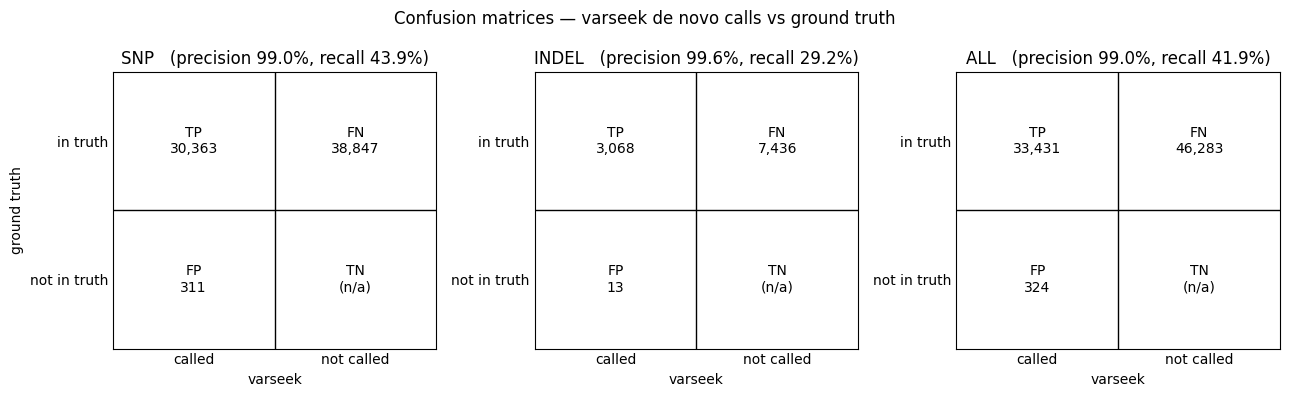

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Authoritative TP / FP / FN straight from the hap.py summary (PASS rows).
summ = pd.read_csv(os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv"))
summ = summ[summ["Filter"] == "PASS"].set_index("Type")
cms = {t: (int(summ.loc[t, "TRUTH.TP"]), int(summ.loc[t, "QUERY.FP"]), int(summ.loc[t, "TRUTH.FN"]))
       for t in ("SNP", "INDEL")}
cms["ALL"] = tuple(sum(v) for v in zip(cms["SNP"], cms["INDEL"]))

print("Confusion counts (FN shown for reference, excluded from the matrices):")
for name, (tp, fp, fn) in cms.items():
    print(f"  {name:5s}  TP={tp:>6,}   FP={fp:>5,}   FN={fn:>6,}   "
          f"precision={tp/(tp+fp):.1%}, recall={tp/(tp+fn):.1%}")

# Plain, color-free matrices: white cells, black text and gridlines.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, (tp, fp, fn)) in zip(axes, cms.items()):
    # rows = GIAB truth (in / not in), cols = varseek call (called / not called).
    # FN (in-truth & not-called) and TN (not-truth & not-called) are excluded.
    cells = [[f"TP\n{tp:,}", f"FN\n{fn:,}"],
             [f"FP\n{fp:,}", "TN\n(n/a)"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cells[i][j], ha="center", va="center", fontsize=10, color="black")
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)   # row 0 at top
    ax.axhline(0.5, color="black", lw=1); ax.axvline(0.5, color="black", lw=1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["called", "not called"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["in truth", "not in truth"])
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color("black")
    ax.set_title(f"{name}   (precision {tp/(tp+fp):.1%}, recall {tp/(tp+fn):.1%})")
    ax.set_xlabel("varseek")
axes[0].set_ylabel("ground truth")
fig.suptitle("Confusion matrices — varseek de novo calls vs ground truth")
plt.tight_layout(); plt.show()


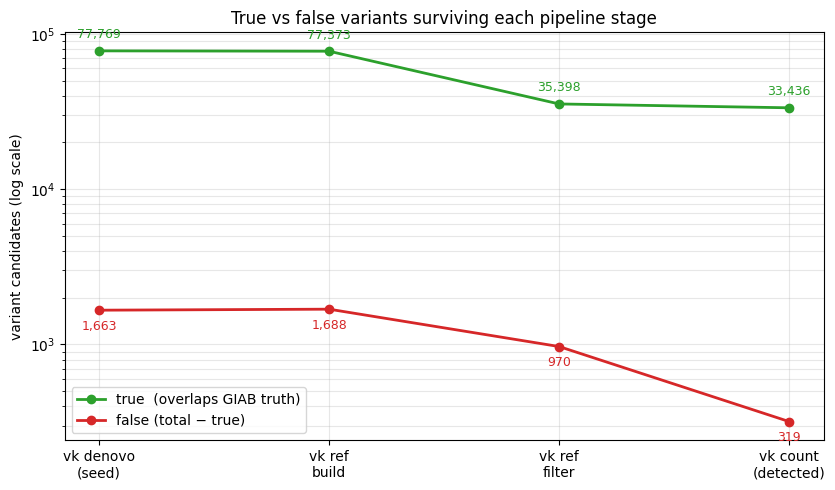

Precision at each stage (true / total):
  vk denovo (seed)           97.9%   (77,769 / 79,432)
  vk ref build               97.9%   (77,373 / 79,061)
  vk ref filter              97.3%   (35,398 / 36,368)
  vk count (detected)        99.1%   (33,436 / 33,755)


In [ ]:
# True vs false variants surviving each pipeline stage.
steps       = ["vk denovo\n(seed)", "vk ref\nbuild", "vk ref\nfilter", "vk count\n(detected)"]
total_steps = funnel["candidates"].to_numpy()
true_steps  = recall_funnel[["in_seed_vcf", "in_built", "in_filtered", "in_detected"]].sum().to_numpy()
false_steps = total_steps - true_steps

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(steps, true_steps,  "o-", color="tab:green", lw=2, label="true  (overlaps GIAB truth)")
ax.plot(steps, false_steps, "o-", color="tab:red",   lw=2, label="false (total − true)")
for x, (t, f) in enumerate(zip(true_steps, false_steps)):
    ax.annotate(f"{t:,}", (x, t), textcoords="offset points", xytext=(0, 9),  ha="center", color="tab:green", fontsize=9)
    ax.annotate(f"{f:,}", (x, f), textcoords="offset points", xytext=(0, -14), ha="center", color="tab:red",   fontsize=9)
ax.set_yscale("log")   # true ~10^4-10^5, false ~10^2-10^3 -> log to see both trends
ax.set_ylabel("variant candidates (log scale)")
ax.set_title("True vs false variants surviving each pipeline stage")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("Precision at each stage (true / total):")
for s, t, tot in zip(steps, true_steps, total_steps):
    print(f"  {s.replace(chr(10),' '):24s}  {t/tot:6.1%}   ({t:,} / {tot:,})")
